In [2]:
import pandas as pd

# Carregar o arquivo CSV
nome_do_arquivo = 'Annotated_data.csv'
df = pd.read_csv(nome_do_arquivo)

pd.reset_option('display.max_colwidth')

display(df.head())

,Id_Number,Patient Question,Distorted part,Dominant Distortion,Secondary Distortion (Optional)
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalization,NaN
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Labeling,Emotional Reasoning
2,4502,So I’ve been dating on and off this guy for a...,NaN,No Distortion,NaN
3,4503,My parents got divorced in 2004. My mother has...,NaN,No Distortion,NaN
4,4504,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Fortune-telling,Emotional Reasoning


In [ ]:
print(df.shape)

(2530, 5)


In [ ]:
# Cria uma nova tabela para realizar as modificações
df_copia = df.head(2530).copy()

print(df_copia.shape)

(2530, 5)


In [ ]:
df_copia.columns = [
    'ID_Numero',
    'Pergunta_Paciente',
    'Parte_Distorcida',
    'Distorcao_Dominante',
    'Distorcao_Secundaria'
]

display(df_copia.head())

,ID_Numero,Pergunta_Paciente,Parte_Distorcida,Distorcao_Dominante,Distorcao_Secundaria
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalization,NaN
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Labeling,Emotional Reasoning
2,4502,So I’ve been dating on and off this guy for a...,NaN,No Distortion,NaN
3,4503,My parents got divorced in 2004. My mother has...,NaN,No Distortion,NaN
4,4504,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Fortune-telling,Emotional Reasoning


In [ ]:
dicionario_distorcoes = {
    'All-or-nothing thinking': 'Pensamento_tudo_ou_nada',
    'Overgeneralization': 'Supergeneralizacao',
    'Mental filter': 'Filtro_mental',
    'Should statements': 'Declaracoes_de_Deveria',
    'Labeling': 'Rotulacao',
    'Personalization': 'Personalizacao',
    'Magnification': 'Maximizacao',
    'Emotional Reasoning': 'Raciocinio_emocional',
    'Mind Reading': 'Leitura_mental',
    'Fortune-telling': 'Adivinhacao'
}

colunas_alvo = ['Distorcao_Dominante', 'Distorcao_Secundaria']

df_copia[colunas_alvo] = df_copia[colunas_alvo].replace(dicionario_distorcoes)

# Substituir 'No Distortion' por Sem distorcao
df_copia[['Distorcao_Dominante', 'Distorcao_Secundaria']] = df_copia[['Distorcao_Dominante', 'Distorcao_Secundaria']].replace({'No Distortion': 'Sem distorcao'})

display(df_copia.head())

,ID_Numero,Pergunta_Paciente,Parte_Distorcida,Distorcao_Dominante,Distorcao_Secundaria
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalizacao,NaN
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Rotulacao,Raciocinio_emocional
2,4502,So I’ve been dating on and off this guy for a...,NaN,Sem distorcao,NaN
3,4503,My parents got divorced in 2004. My mother has...,NaN,Sem distorcao,NaN
4,4504,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Adivinhacao,Raciocinio_emocional


In [ ]:
# Descrição das distorções
contagem_groupby = df_copia.groupby('Distorcao_Dominante').size().sort_values(ascending=False)

print(contagem_groupby)

Distorcao_Dominante
Sem distorcao              933
Leitura_mental             239
Supergeneralizacao         239
Maximizacao                195
Rotulacao                  165
Personalizacao             153
Adivinhacao                143
Raciocinio_emocional       134
Filtro_mental              122
Declaracoes_de_Deveria     107
Pensamento_tudo_ou_nada    100
dtype: int64


In [ ]:
# Descrição das distorções secundarias
contagem_groupby = df_copia.groupby('Distorcao_Secundaria').size().sort_values(ascending=False)

print(contagem_groupby)

Distorcao_Secundaria
Adivinhacao                67
Leitura_mental             56
Maximizacao                50
Personalizacao             49
Supergeneralizacao         38
Rotulacao                  38
Raciocinio_emocional       35
Filtro_mental              29
Declaracoes_de_Deveria     28
Pensamento_tudo_ou_nada    26
dtype: int64


In [ ]:
# Verifica o total de nulos para cada coluna do dataset
print(df_copia.isna().sum())

ID_Numero                  0
Pergunta_Paciente          0
Parte_Distorcida         933
Distorcao_Dominante        0
Distorcao_Secundaria    2114
dtype: int64


In [ ]:
#Substituir NaN por Nenhuma na Parte_Distorcida
df_copia['Parte_Distorcida'] = df_copia['Parte_Distorcida'].fillna('Nenhuma')

#Substituir NaN por Sem distorção na Distorcao_Secundaria
df_copia['Distorcao_Secundaria'] = df_copia['Distorcao_Secundaria'].fillna('Sem distorcao')

display(df_copia.head())

,ID_Numero,Pergunta_Paciente,Parte_Distorcida,Distorcao_Dominante,Distorcao_Secundaria
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalizacao,Sem distorcao
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Rotulacao,Raciocinio_emocional
2,4502,So I’ve been dating on and off this guy for a...,Nenhuma,Sem distorcao,Sem distorcao
3,4503,My parents got divorced in 2004. My mother has...,Nenhuma,Sem distorcao,Sem distorcao
4,4504,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Adivinhacao,Raciocinio_emocional


In [ ]:
# Verifica o total de nulos do dataset
print(df_copia.isna().sum())

ID_Numero               0
Pergunta_Paciente       0
Parte_Distorcida        0
Distorcao_Dominante     0
Distorcao_Secundaria    0
dtype: int64


In [ ]:
# Pegando a frase da primeira linha, coluna 'Pergunta_Paciente'
frase_completa = df_copia.loc[0, 'Pergunta_Paciente']

print(frase_completa)

Hello, I have a beautiful,smart,outgoing and amazing five year old little girl. Yesterday she came to me and said mom can you take me to the doctor. I ask her what was wrong and she replied: I hear voices in my ears but I dont see the people saying it. She says it happened during school doing a reading circle. She thought someone called her stupid and let the teacher know. The teacher said no one said anything. It happened again when my husband was talking to my other children, she said I heard daddy say shut up, but he didnt really say it. The voice are always fimilar (someone she knows) Im very concerned about this and hope it has nothing to do with my pregnancy while on active duty.


In [ ]:
# Pegando a frase da linha primeira linha, coluna 'Parte_Distorcida' para ver se bate na tradução do google mesmo
frase_completa = df_copia.loc[0, 'Parte_Distorcida']

print(frase_completa)

The voice are always fimilar (someone she knows) Im very concerned about this and hope it has nothing to do with my pregnancy while on active duty.


Na tradução do google teve uma  leve alteração na ultima parte que fala do serviço militar. na primeira linha a 'Pergunta_Paciente' esta como: As vozes são sempre familiares (de alguém que ela conhece). Estou muito preocupada com isso e espero que não tenha nada a ver com a minha gravidez enquanto estou em serviço militar.

Já na parte distorcida: A voz é sempre familiar (de alguém que ela conhece). Estou muito preocupada com isso e espero que não tenha nada a ver com a minha gravidez durante o serviço militar ativo

A mudança nesse exemplo estando no final e no inicio, mas a essencial de Personalização que é quando a pessoa atribui a si mesma uma culpa desproporcional por eventos negativos que em sua maioria não estão sob a sua responsabilidade, incluindo acontecimentos na vida de outras pessoas.

In [ ]:
#df_copia.to_csv('dataset_traduzido_parcial.csv', index=False)

In [ ]:
!pip install deep_translator
!python -m spacy download pt_core_news_sm


!pip install transformers sentencepiece torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 107.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import torch
import pandas as pd
from transformers import MarianMTModel, MarianTokenizer
from tqdm.notebook import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

# carregar modelo
MODEL_NAME = "Helsinki-NLP/opus-mt-en-ROMANCE"
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model = MarianMTModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print("Modelo pronto!")


# funçao de traduçao
def traduzir_coluna(series, batch_size=20):
    textos = series.tolist()
    resultados = []

    for i in tqdm(range(0, len(textos), batch_size)):
        lote = textos[i : i + batch_size]
        validos, mapa = [], {}

        for j, t in enumerate(lote):
            if pd.isna(t) or str(t).strip().lower() in ['none', 'nenhuma', '', 'nan']:
                mapa[j] = ('especial', t)
            else:
                mapa[j] = ('traduzir', len(validos))
                validos.append(">>pt_BR<< " + str(t).strip()) # estava sendo traduzido para pt-pt, ea frase mudava muito de sentido

        traduzidos = []
        if validos:
            try:
                tokens = tokenizer(validos, return_tensors="pt", padding=True,truncation=True, max_length=512).to(device)
                with torch.no_grad():
                    saida = model.generate(**tokens, num_beams=4,max_length=512, early_stopping=True)
                traduzidos = tokenizer.batch_decode(saida, skip_special_tokens=True)

            except RuntimeError as e:
                # traduz um por um e continua
                print(f"\nMemória insuficiente {i//batch_size + 1} traduzindo individualmente.")
                torch.cuda.empty_cache()
                for texto in validos:
                    tok = tokenizer([texto], return_tensors="pt",
                                    truncation=True, max_length=512).to(device)
                    with torch.no_grad():
                        s = model.generate(**tok, num_beams=4,
                                           max_length=512, early_stopping=True)
                    traduzidos.append(tokenizer.decode(s[0], skip_special_tokens=True))

        torch.cuda.empty_cache()

        for j in range(len(lote)):
            tipo, val = mapa[j]
            resultados.append(val if tipo == 'especial' else traduzidos[val])

    return resultados

# traduzir
df_copia['Pergunta_Paciente'] = traduzir_coluna(df_copia['Pergunta_Paciente'], batch_size=10)
df_copia['Parte_Distorcida'] = traduzir_coluna(df_copia['Parte_Distorcida'], batch_size=10)

print("\nConcluído!")
display(df_copia.head(5))

Dispositivo: cuda


tokenizer_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/779k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/799k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

...

Modelo pronto!


  0%|          | 0/253 [00:00<?, ?it/s]

  0%|          | 0/253 [00:00<?, ?it/s]


Concluído!


,ID_Numero,Pergunta_Paciente,Parte_Distorcida,Distorcao_Dominante,Distorcao_Secundaria
0,4500,"Olá, eu tenho uma menina bonita, inteligente, ...",A voz é sempre fimilar (alguém que ela conhece...,Personalizacao,Sem distorcao
1,4501,"Desde que eu tinha cerca de 16 anos de idade, ...",Eu me sinto preso dentro do meu eu nojento e c...,Rotulacao,Raciocinio_emocional
2,4502,Então ele me deixava namorar e sair com este c...,Nenhuma,Sem distorcao,Sem distorcao
3,4503,Meus pais se divorciaram em 2004. Minha mãe nu...,Nenhuma,Sem distorcao,Sem distorcao
4,4504,"Eu realmente não sei como explicar a situação,...",Eu me recusei a ir porque não sabia se ia entr...,Adivinhacao,Raciocinio_emocional


In [ ]:
frase_completa = df_copia.loc[0, 'Parte_Distorcida']

print(frase_completa)

A voz é sempre fimilar (alguém que ela conhece) Estou muito preocupado com isso e espero que não tenha nada a ver com a minha gravidez enquanto está em serviço ativo.


In [ ]:
frase_completa = df_copia.loc[0, 'Pergunta_Paciente']

print(frase_completa)

Olá, eu tenho uma menina bonita, inteligente, extraordinária e incrível de cinco anos. Ontem ela veio até mim e disse que a mãe pode levar- me ao médico. Perguntei- lhe o que estava errado e ela respondeu: Eu ouço vozes nos meus ouvidos, mas eu não vejo as pessoas dizendo isso. Ela diz que aconteceu durante a escola fazendo um círculo de leitura. Ela pensou que alguém a chamou de estúpida e avisar o professor. A professora não disse nada. Aconteceu novamente quando meu marido estava falando com meus outros filhos, ela disse que eu ouvi papai dizer calado, mas ele realmente não disse isso. A voz é sempre fimilar (alguém que ela conhece) Estou muito preocupado com isso e espero que não tenha nada a ver com a minha gravidez enquanto estava em serviço ativo.


In [ ]:
#df_copia.to_csv('dataset_traduzido_V4_2500.csv', index=False) 27m

PRE-PROCESSAMENTO, VETORIZAÇÃO E TREINAMENTO

In [3]:
!pip install nltk spacy -q
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 74.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import re
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import spacy
nlp_pt = spacy.load("pt_core_news_sm", disable=["parser", "ner"])

RANDOM_STATE = 42

In [5]:
CAMINHO_ARQUIVO = "dataset_traduzido_V4_completo.csv"

df_bin = pd.read_csv(CAMINHO_ARQUIVO)
print("Total de linhas:", len(df_bin))

# 1 = tem distorção | 0 = Sem distorção
df_bin["tem_distorcao"] = (df_bin["Distorcao_Dominante"] != "Sem distorcao").astype(int)

print("\nDistribuiçao binaria:")
print(df_bin["tem_distorcao"].value_counts())

df_copia = df_bin.head(2530).copy()
print(df_copia.shape)

df_copia.head()

Total de linhas: 2530

Distribuiçao binaria:
tem_distorcao
1    1597
0     933
Name: count, dtype: int64
(2530, 6)


,ID_Numero,Pergunta_Paciente,Parte_Distorcida,Distorcao_Dominante,Distorcao_Secundaria,tem_distorcao
0,4500,"Olá, eu tenho uma menina bonita, inteligente, ...",A voz é sempre fimilar (alguém que ela conhece...,Personalizacao,Sem distorcao,1
1,4501,"Desde que eu tinha cerca de 16 anos de idade, ...",Eu me sinto preso dentro do meu eu nojento e c...,Rotulacao,Raciocinio_emocional,1
2,4502,Então ele me deixava namorar e sair com este c...,Nenhuma,Sem distorcao,Sem distorcao,0
3,4503,Meus pais se divorciaram em 2004. Minha mãe nu...,Nenhuma,Sem distorcao,Sem distorcao,0
4,4504,"Eu realmente não sei como explicar a situação,...",Eu me recusei a ir porque não sabia se ia entr...,Adivinhacao,Raciocinio_emocional,1


In [6]:
stop_words = set(stopwords.words('portuguese'))
# tentei fazer desse jeito

# Negaçao/intensidade e alguns pronomes preservados
# ex: não, sempre, eu, "ele/ela")
palavras_manter = {
    "não", "nao", "nunca", "jamais", "nenhum", "nenhuma", "nada", "ninguém",
    "ninguem", "sempre", "todo", "toda", "todos", "todas", "tudo",
    "deveria", "deve", "deverei", "devia", "precisa", "precisava",
    "muito", "muita", "muitos", "muitas", "mais", "menos", "mas",
    "eu", "me", "meu", "minha", "meus", "minhas",
    "ele", "ela", "eles", "elas", "nós", "nos",
    "você", "vocês", "tu", "te", "ti", "teu", "tua", "teus", "tuas",
    "nosso", "nossa", "nossos", "nossas", "lhe", "lhes", "se"
}
stop_words = stop_words - palavras_manter

# Acentos preservados
PADRAO_CARACTERES = r"[^a-zA-ZáàâãéêíóôõúçÁÀÂÃÉÊÍÓÔÕÚÇ\s]"

In [7]:
def preprocessar_texto(texto):
    if not isinstance(texto, str):
        return ""

    # 1 Minusculas
    texto = texto.lower()

    # 2 Remoçao de urls e correçao de artefato de tradução no propio ingles tinha (fmily) referente a family
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"(\w)- (\w)", r"\1-\2", texto)

    # 3 Remoçao de caracteres nao alfabeticos preserva acentos
    texto = re.sub(PADRAO_CARACTERES, " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    if not texto:
        return ""

    # 4 Remoçao de stopwords
    tokens = [t for t in texto.split() if t not in stop_words and len(t) > 1]
    if not tokens:
        return ""

    # 5 Lematizaçao
    doc = nlp_pt(" ".join(tokens))
    lemas = [token.lemma_ for token in doc]

    return " ".join(lemas)

In [8]:
df_copia["texto_processado"] = df_copia["Pergunta_Paciente"].apply(preprocessar_texto)
df_copia = df_copia[df_copia["texto_processado"].str.len() > 0].reset_index(drop=True)

print("Linhas apos limpeza:", len(df_copia))

Linhas apos limpeza: 2530


In [9]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(df_copia["texto_processado"], df_copia["tem_distorcao"],
    test_size=0.3, random_state=RANDOM_STATE, stratify=df_copia["tem_distorcao"]
)

print(f"Treino: {len(X_train_bin)} | Teste: {len(X_test_bin)}")
print(y_train_bin.value_counts(normalize=True))

Treino: 1771 | Teste: 759
tem_distorcao
1    0.631282
0    0.368718
Name: proportion, dtype: float64


In [10]:
# Vetorização com o TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bin = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2, max_df=0.9)
X_train_tfidf_bin = tfidf_bin.fit_transform(X_train_bin)
X_test_tfidf_bin = tfidf_bin.transform(X_test_bin)

print("Dimensao TF-IDF (treino):", X_train_tfidf_bin.shape)

Dimensao TF-IDF (treino): (1771, 8000)


SVM

In [11]:
#SVM
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              make_scorer, classification_report, confusion_matrix)

cv_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_bin = {"accuracy": "accuracy","precision": make_scorer(precision_score, average="macro", zero_division=0),"recall": make_scorer(recall_score, average="macro", zero_division=0),"f1_score": make_scorer(f1_score, average="macro"),}

# tentei colocar de dois jeitos, esse valores é utilizando o svm de forma padrão sem os parametros para ajustar o desbalanceamento
#SVM (Detecção binaria) tem ou não tem
#Accuracy (media):  0.7058
#Precisão (media):  0.7833
#Recall (media):    0.7397
#F1 (media):        0.7604

svm_bin = SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)
scores_bin = cross_validate(svm_bin, X_train_tfidf_bin, y_train_bin, cv=cv_bin, scoring=scoring_bin)

# Validação cruzada
print("SVM (Detecção binária) tem ou não tem")
print(f"Accuracy:  {scores_bin['test_accuracy'].mean():.4f}")
print(f"Precisão:  {scores_bin['test_precision'].mean():.4f}")
print(f"Recall:    {scores_bin['test_recall'].mean():.4f}")
print(f"F1-Score:  {scores_bin['test_f1_score'].mean():.4f}")

SVM (Detecção binária) tem ou não tem
Accuracy:  0.7058
Precisão:  0.6880
Recall:    0.6937
F1-Score:  0.6892


SVM (Detecção binária) - Avaliação
Accuracy:  0.6706192358366272
Precisão:  0.6516991163158272
Recall:    0.6574336415150611
F1-Score:  0.65343731735827
                   precision    recall  f1-score   support

Sem distorção (0)       0.55      0.61      0.58       280
Tem distorção (1)       0.76      0.71      0.73       479

         accuracy                           0.67       759
        macro avg       0.65      0.66      0.65       759
     weighted avg       0.68      0.67      0.67       759



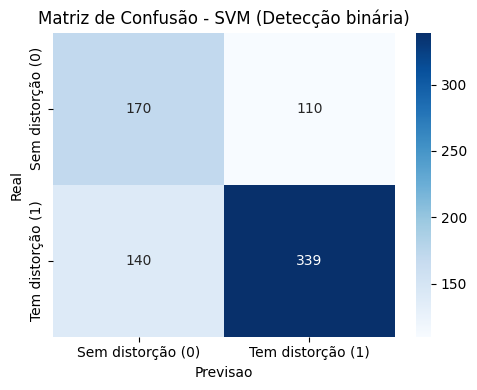

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score

svm_bin.fit(X_train_tfidf_bin, y_train_bin)
y_pred_bin = svm_bin.predict(X_test_tfidf_bin)


# valores com base utilizando o metodo padrão, com pouca diferença
#Accuracy:  0.6706192358366272
#Precisão:  0.755011135857461
#Recall:    0.7077244258872651
#F1-Score:  0.7306034482758621
                   #precision    recall  f1-score   support

#Sem distorção (0)       0.55      0.61      0.58       280
#Tem distorção (1)       0.76      0.71      0.73       479

         #accuracy                           0.67       759
        #macro avg       0.65      0.66      0.65       759
     #weighted avg       0.68      0.67      0.67       759


print("SVM (Detecção binária) - Avaliação")
print("Accuracy: ", accuracy_score(y_test_bin, y_pred_bin))
print("Precisão: ", precision_score(y_test_bin, y_pred_bin, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_bin, y_pred_bin, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_bin, y_pred_bin, average="macro"))
print(classification_report(y_test_bin, y_pred_bin, target_names=["Sem distorção (0)", "Tem distorção (1)"], zero_division=0))


cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues", xticklabels=["Sem distorção (0)", "Tem distorção (1)"], yticklabels=["Sem distorção (0)", "Tem distorção (1)"])
plt.title("Matriz de Confusão - SVM (Detecção binária)")
plt.xlabel("Previsao"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig("matriz_confusao_SVM_binario.png", dpi=150)
plt.show()

SVM UTILIZANDO PARTE DISTORCIDA

In [13]:
df_tipo = df_bin[df_bin["Distorcao_Dominante"] != "Sem distorcao"].copy().reset_index(drop=True)

print("Total de linhas:", len(df_tipo))
print("\nDistribuição das 10 classes:")
print(df_tipo["Distorcao_Dominante"].value_counts())

Total de linhas: 1597

Distribuição das 10 classes:
Distorcao_Dominante
Supergeneralizacao         239
Leitura_mental             239
Maximizacao                195
Rotulacao                  165
Personalizacao             153
Adivinhacao                143
Raciocinio_emocional       134
Filtro_mental              122
Declaracoes_de_Deveria     107
Pensamento_tudo_ou_nada    100
Name: count, dtype: int64


In [14]:
df_tipo["texto_processado"] = df_tipo["Parte_Distorcida"].apply(preprocessar_texto)
df_tipo = df_tipo[df_tipo["texto_processado"].str.len() > 0].reset_index(drop=True)

print("\nExemplo:")
print("Original:", df_tipo["Parte_Distorcida"].iloc[0])
print("Processado:", df_tipo["texto_processado"].iloc[0])


Exemplo:
Original: A voz é sempre fimilar (alguém que ela conhece) Estou muito preocupado com isso e espero que não tenha nada a ver com a minha gravidez enquanto está em serviço ativo.
Processado: voz sempre fimilar alguém ela conhecer muito preocupado esperar não nada ver meu gravidez enquanto serviço ativo


In [15]:
from sklearn.preprocessing import LabelEncoder

le_tipo = LabelEncoder()
y_tipo = le_tipo.fit_transform(df_tipo["Distorcao_Dominante"])
X_texto_tipo = df_tipo["texto_processado"]

print("Classes codificadas:")
for i, classe in enumerate(le_tipo.classes_):
    print(f"  {i} -> {classe}")

X_train_tipo, X_test_tipo, y_train_tipo, y_test_tipo = train_test_split(
    X_texto_tipo, y_tipo, test_size=0.3, random_state=RANDOM_STATE, stratify=y_tipo
)
print(f"\nTreino: {len(X_train_tipo)} | Teste: {len(X_test_tipo)}")

Classes codificadas:
  0 -> Adivinhacao
  1 -> Declaracoes_de_Deveria
  2 -> Filtro_mental
  3 -> Leitura_mental
  4 -> Maximizacao
  5 -> Pensamento_tudo_ou_nada
  6 -> Personalizacao
  7 -> Raciocinio_emocional
  8 -> Rotulacao
  9 -> Supergeneralizacao

Treino: 1117 | Teste: 480


In [16]:
# vetorização novamente
tfidf_tipo = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2, max_df=0.9)
X_train_tfidf_tipo = tfidf_tipo.fit_transform(X_train_tipo)
X_test_tfidf_tipo = tfidf_tipo.transform(X_test_tipo)

print("Dimensão TF-IDF (treino):", X_train_tfidf_tipo.shape)

Dimensão TF-IDF (treino): (1117, 4083)


In [17]:
cv_tipo = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_tipo = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "recall": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_score": make_scorer(f1_score, average="macro"),
}

svm_tipo = SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)
scores_tipo = cross_validate(svm_tipo, X_train_tfidf_tipo, y_train_tipo, cv=cv_tipo, scoring=scoring_tipo)


print("SVM (Classificação de tipos)")
print(f"Accuracy: {scores_tipo['test_accuracy'].mean():.4f}")
print(f"Precisão: {scores_tipo['test_precision'].mean():.4f}")
print(f"Recall:   {scores_tipo['test_recall'].mean():.4f}")
print(f"F1-Score: {scores_tipo['test_f1_score'].mean():.4f}")

SVM (Classificação de tipos)
Accuracy: 0.2901
Precisão: 0.2948
Recall:   0.2683
F1-Score: 0.2733


SVM (Classificação de tipos) - Avaliação final
Accuracy:  0.29583333333333334
Precisão:  0.2801496301864314
Recall:    0.2696537877081698
F1-Score:  0.2730930093401289
                         precision    recall  f1-score   support

            Adivinhacao       0.17      0.14      0.15        43
 Declaracoes_de_Deveria       0.45      0.31      0.37        32
          Filtro_mental       0.13      0.16      0.14        37
         Leitura_mental       0.50      0.54      0.52        72
            Maximizacao       0.18      0.20      0.19        59
Pensamento_tudo_ou_nada       0.14      0.13      0.14        30
         Personalizacao       0.33      0.30      0.31        46
   Raciocinio_emocional       0.22      0.23      0.22        40
              Rotulacao       0.29      0.29      0.29        49
     Supergeneralizacao       0.39      0.39      0.39        72

               accuracy                           0.30       480
              macro avg       0.28      0.27      

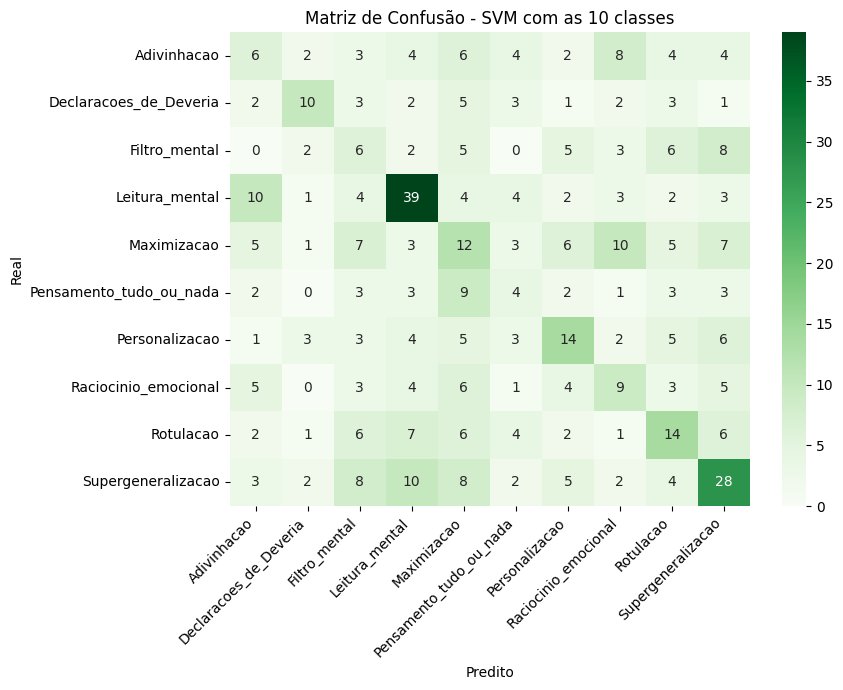

In [18]:
svm_tipo.fit(X_train_tfidf_tipo, y_train_tipo)
y_pred_tipo = svm_tipo.predict(X_test_tfidf_tipo)

print("SVM (Classificação de tipos) - Avaliação final")
print("Accuracy: ", accuracy_score(y_test_tipo, y_pred_tipo))
print("Precisão: ", precision_score(y_test_tipo, y_pred_tipo, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_tipo, y_pred_tipo, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_tipo, y_pred_tipo, average="macro"))
print(classification_report(y_test_tipo, y_pred_tipo, target_names=le_tipo.classes_, zero_division=0))


cm_tipo = confusion_matrix(y_test_tipo, y_pred_tipo)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_tipo, annot=True, fmt="d", cmap="Greens",xticklabels=le_tipo.classes_, yticklabels=le_tipo.classes_)
plt.title("Matriz de Confusão - SVM com as 10 classes")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("matriz_confusao_SVM_tipo.png", dpi=150)
plt.show()

TREE DESICION BINARIO

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree_bin = DecisionTreeClassifier(class_weight="balanced", criterion="gini", max_depth=10, random_state=RANDOM_STATE)

scores_tree_bin = cross_validate(tree_bin, X_train_tfidf_bin, y_train_bin, cv=cv_bin, scoring=scoring_bin)  # aproveitando a primeira vetorização

# validação cruzada
print("Decision Tree (Detecção binária)")
print(f"Accuracy: {scores_tree_bin['test_accuracy'].mean():.4f}")
print(f"Precisão: {scores_tree_bin['test_precision'].mean():.4f}")
print(f"Recall:   {scores_tree_bin['test_recall'].mean():.4f}")
print(f"F1-Score: {scores_tree_bin['test_f1_score'].mean():.4f}")

tree_bin.fit(X_train_tfidf_bin, y_train_bin)
y_pred_tree_bin = tree_bin.predict(X_test_tfidf_bin)


print("\nDecision Tree - Avaliação")
print("Accuracy: ", accuracy_score(y_test_bin, y_pred_tree_bin))
print("Precisão: ", precision_score(y_test_bin, y_pred_tree_bin, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_bin, y_pred_tree_bin, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_bin, y_pred_tree_bin, average="macro"))
print(classification_report(y_test_bin, y_pred_tree_bin, target_names=["Sem distorção (0)", "Tem distorção (1)"], zero_division=0))

Decision Tree (Detecção binária)
Accuracy: 0.6115
Precisão: 0.6040
Recall:   0.6101
F1-Score: 0.5999

Decision Tree - Avaliação
Accuracy:  0.5783926218708827
Precisão:  0.5820825515947468
Recall:    0.5880741127348643
F1-Score:  0.5725147845677274
                   precision    recall  f1-score   support

Sem distorção (0)       0.45      0.62      0.52       280
Tem distorção (1)       0.72      0.55      0.62       479

         accuracy                           0.58       759
        macro avg       0.58      0.59      0.57       759
     weighted avg       0.62      0.58      0.59       759



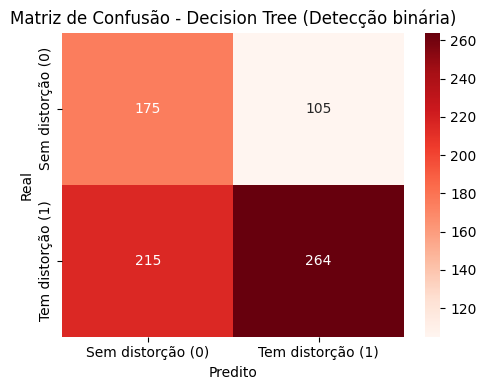

In [20]:
cm_tree_bin = confusion_matrix(y_test_bin, y_pred_tree_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree_bin, annot=True, fmt="d", cmap="Reds",xticklabels=["Sem distorção (0)", "Tem distorção (1)"],yticklabels=["Sem distorção (0)", "Tem distorção (1)"])
plt.title("Matriz de Confusão - Decision Tree (Detecção binária)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig("matriz_confusao_DecisionTree_binario.png", dpi=150)
plt.show()

TREE PARTE DISTORCIDA

In [23]:
tree_tipo = DecisionTreeClassifier(class_weight="balanced", criterion="gini", max_depth=None, random_state=RANDOM_STATE)

# utilizando o None ficou um pouco melhor do que limitando a 10 como antes na binária

scores_tree_tipo = cross_validate(tree_tipo, X_train_tfidf_tipo, y_train_tipo, cv=cv_tipo, scoring=scoring_tipo)

#Validação cruzada
print("Decision Tree (Classificação de tipos)")
print(f"Accuracy: {scores_tree_tipo['test_accuracy'].mean():.4f}")
print(f"Precisão: {scores_tree_tipo['test_precision'].mean():.4f}")
print(f"Recall:   {scores_tree_tipo['test_recall'].mean():.4f}")
print(f"F1-Score: {scores_tree_tipo['test_f1_score'].mean():.4f}")

tree_tipo.fit(X_train_tfidf_tipo, y_train_tipo)
y_pred_tree_tipo = tree_tipo.predict(X_test_tfidf_tipo)

print("\nDecision Tree (Classificação de tipos) - Avaliação final")
print("Accuracy: ", accuracy_score(y_test_tipo, y_pred_tree_tipo))
print("Precisão: ", precision_score(y_test_tipo, y_pred_tree_tipo, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_tipo, y_pred_tree_tipo, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_tipo, y_pred_tree_tipo, average="macro"))
print(classification_report(y_test_tipo, y_pred_tree_tipo, target_names=le_tipo.classes_, zero_division=0))

Decision Tree (Classificação de tipos)
Accuracy: 0.1934
Precisão: 0.2005
Recall:   0.1958
F1-Score: 0.1939

Decision Tree (Classificação de tipos) - Avaliação final
Accuracy:  0.20208333333333334
Precisão:  0.2066953383812161
Recall:    0.20128655280504035
F1-Score:  0.20179634778327057
                         precision    recall  f1-score   support

            Adivinhacao       0.19      0.21      0.20        43
 Declaracoes_de_Deveria       0.45      0.41      0.43        32
          Filtro_mental       0.05      0.05      0.05        37
         Leitura_mental       0.30      0.19      0.24        72
            Maximizacao       0.22      0.17      0.19        59
Pensamento_tudo_ou_nada       0.09      0.10      0.09        30
         Personalizacao       0.23      0.24      0.24        46
   Raciocinio_emocional       0.16      0.20      0.18        40
              Rotulacao       0.16      0.20      0.18        49
     Supergeneralizacao       0.22      0.24      0.23       

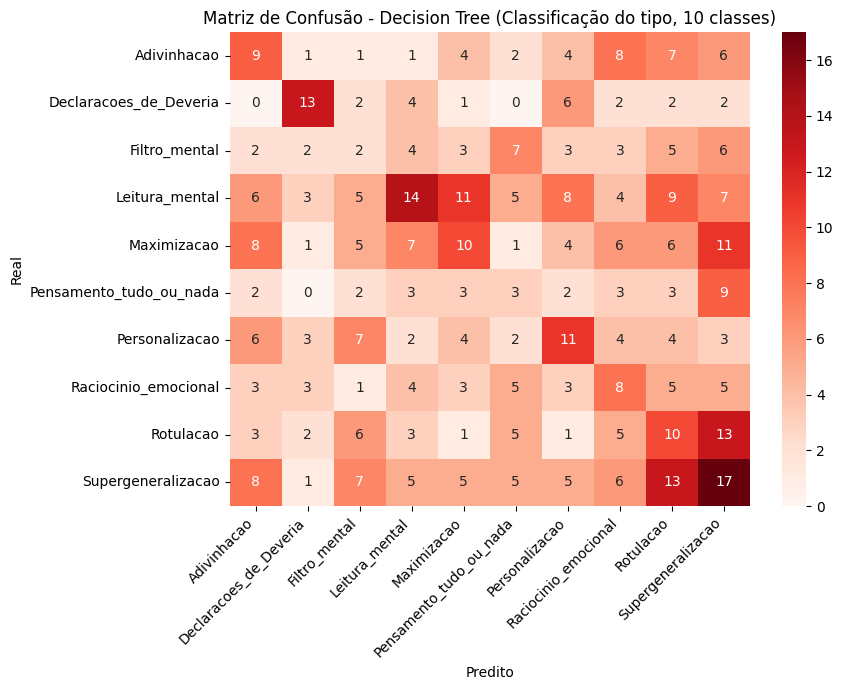

In [24]:
cm_tree_tipo = confusion_matrix(y_test_tipo, y_pred_tree_tipo)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_tree_tipo, annot=True, fmt="d", cmap="Reds",
            xticklabels=le_tipo.classes_, yticklabels=le_tipo.classes_)
plt.title("Matriz de Confusão - Decision Tree (Classificação do tipo, 10 classes)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("matriz_confusao_DecisionTree_tipo.png", dpi=150)
plt.show()

NAIVE BAYES BINARIO

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

count_bin = CountVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2, max_df=0.9) # mudando  a vetorização para usar o Naive
X_train_count_bin = count_bin.fit_transform(X_train_bin)
X_test_count_bin = count_bin.transform(X_test_bin)

print("Dimensão CountVectorizer (treino):", X_train_count_bin.shape)

Dimensão CountVectorizer (treino): (1771, 8000)


In [26]:
from sklearn.naive_bayes import ComplementNB, MultinomialNB

#nb_bin = MultinomialNB()
nb_bin = ComplementNB()
scores_nb_bin = cross_validate(nb_bin, X_train_count_bin, y_train_bin, cv=cv_bin, scoring=scoring_bin)

# Validação cruzada
print("Naive Bayes (Detecção binária)")
print(f"Accuracy: {scores_nb_bin['test_accuracy'].mean():.4f}")
print(f"Precisão: {scores_nb_bin['test_precision'].mean():.4f}")
print(f"Recall:   {scores_nb_bin['test_recall'].mean():.4f}")
print(f"F1-Score: {scores_nb_bin['test_f1_score'].mean():.4f}")

Naive Bayes (Detecção binária)
Accuracy: 0.6878
Precisão: 0.6716
Recall:   0.6788
F1-Score: 0.6729



Naive Bayes (Detecção binária) - Avaliação
Accuracy:  0.6851119894598156
Precisão:  0.6661309849816955
Recall:    0.6718833880107367
F1-Score:  0.6680658814229539
                   precision    recall  f1-score   support

Sem distorção (0)       0.57      0.62      0.59       280
Tem distorção (1)       0.77      0.72      0.74       479

         accuracy                           0.69       759
        macro avg       0.67      0.67      0.67       759
     weighted avg       0.69      0.69      0.69       759



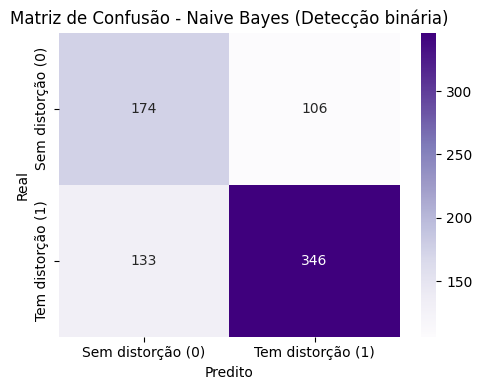

In [27]:
nb_bin.fit(X_train_count_bin, y_train_bin)
y_pred_nb_bin = nb_bin.predict(X_test_count_bin)


print("\nNaive Bayes (Detecção binária) - Avaliação")
print("Accuracy: ", accuracy_score(y_test_bin, y_pred_nb_bin))
print("Precisão: ", precision_score(y_test_bin, y_pred_nb_bin, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_bin, y_pred_nb_bin, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_bin, y_pred_nb_bin, average="macro"))
print(classification_report(y_test_bin, y_pred_nb_bin, target_names=["Sem distorção (0)", "Tem distorção (1)"], zero_division=0))

cm_nb_bin = confusion_matrix(y_test_bin, y_pred_nb_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb_bin, annot=True, fmt="d", cmap="Purples",xticklabels=["Sem distorção (0)", "Tem distorção (1)"],yticklabels=["Sem distorção (0)", "Tem distorção (1)"])
plt.title("Matriz de Confusão - Naive Bayes (Detecção binária)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig("matriz_confusao_NB_binario.png", dpi=150)
plt.show()

NB PARTE DISTORCIDA

In [28]:
count_tipo = CountVectorizer(ngram_range=(1, 2), max_features=8000, min_df=2, max_df=0.9)
X_train_count_tipo = count_tipo.fit_transform(X_train_tipo)
X_test_count_tipo = count_tipo.transform(X_test_tipo)

In [29]:
nb_tipo = ComplementNB(alpha=1.0)

scores_nb_tipo = cross_validate(nb_tipo, X_train_count_tipo, y_train_tipo, cv=cv_tipo, scoring=scoring_tipo)

# Validação cruzada
print("Naive Bayes (Classificação de tipos)")
print(f"Accuracy: {scores_nb_tipo['test_accuracy'].mean():.4f}")
print(f"Precisão: {scores_nb_tipo['test_precision'].mean():.4f}")
print(f"Recall:   {scores_nb_tipo['test_recall'].mean():.4f}")
print(f"F1-Score: {scores_nb_tipo['test_f1_score'].mean():.4f}")

nb_tipo.fit(X_train_count_tipo, y_train_tipo)
y_pred_nb_tipo = nb_tipo.predict(X_test_count_tipo)

print("\nNaive Bayes (Classificação de tipos) - Avaliação final")
print("Accuracy: ", accuracy_score(y_test_tipo, y_pred_nb_tipo))
print("Precisão: ", precision_score(y_test_tipo, y_pred_nb_tipo, average="macro", zero_division=0))
print("Recall:   ", recall_score(y_test_tipo, y_pred_nb_tipo, average="macro", zero_division=0))
print("F1-Score: ", f1_score(y_test_tipo, y_pred_nb_tipo, average="macro"))
print(classification_report(y_test_tipo, y_pred_nb_tipo, target_names=le_tipo.classes_, zero_division=0))

Naive Bayes (Classificação de tipos)
Accuracy: 0.2552
Precisão: 0.2428
Recall:   0.2431
F1-Score: 0.2377

Naive Bayes (Classificação de tipos) - Avaliação final
Accuracy:  0.29583333333333334
Precisão:  0.2762844668558265
Recall:    0.27015390125716
F1-Score:  0.26816007796265307
                         precision    recall  f1-score   support

            Adivinhacao       0.19      0.12      0.14        43
 Declaracoes_de_Deveria       0.48      0.31      0.38        32
          Filtro_mental       0.11      0.11      0.11        37
         Leitura_mental       0.41      0.60      0.49        72
            Maximizacao       0.22      0.24      0.23        59
Pensamento_tudo_ou_nada       0.15      0.13      0.14        30
         Personalizacao       0.29      0.30      0.29        46
   Raciocinio_emocional       0.24      0.20      0.22        40
              Rotulacao       0.38      0.43      0.40        49
     Supergeneralizacao       0.31      0.26      0.29        72

  

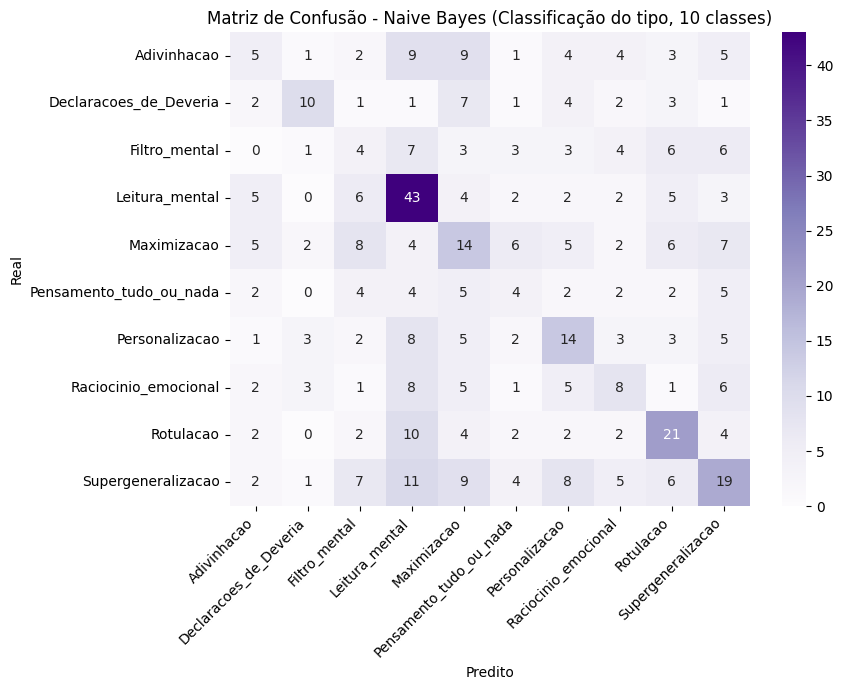

In [30]:
cm_nb_tipo = confusion_matrix(y_test_tipo, y_pred_nb_tipo)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_nb_tipo, annot=True, fmt="d", cmap="Purples",
            xticklabels=le_tipo.classes_, yticklabels=le_tipo.classes_)
plt.title("Matriz de Confusão - Naive Bayes (Classificação do tipo, 10 classes)")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("matriz_confusao_NB_tipo.png", dpi=150)
plt.show()

In [ ]:
# Utilizando as 4 metricas na avaliação

#Tabela: Resultados do Desempenho dos Algoritmos de Classificação Binario tem ou não tem
               #Algoritmos  Acurácia  Precisão  Recall  F1-Score
#Support Vector Classifier    0.6706    0.6517  0.6574    0.6534
 #Decision Tree Classifier    0.5784    0.5821  0.5881    0.5725
              #Naive Bayes    0.6851    0.6661  0.6719    0.6681

#Tabela: Resultados do Desempenho dos Algoritmos de Classificação Tipos
               #Algoritmos  Acurácia  Precisão  Recall  F1-Score
#Support Vector Classifier    0.2958    0.2801  0.2697    0.2731
 #Decision Tree Classifier    0.2021    0.2067  0.2013    0.2018
              #Naive Bayes    0.2958    0.2763  0.2702    0.2682